# OpenCV 기하학적 변환 실습

## 학습 목표
1. 다양한 필터 적용하기
2. 이미지 회전, 확대, 축소 마스터하기
3. Affine 변환으로 이미지 왜곡하기
4. Perspective 변환으로 원근감 표현하기
5. 실전 문제 해결하기

In [ ]:
# 환경 설정
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import urllib.request

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Dejavu Sans' # 기본폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 설정(마이너스 기호 깨짐 방지)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
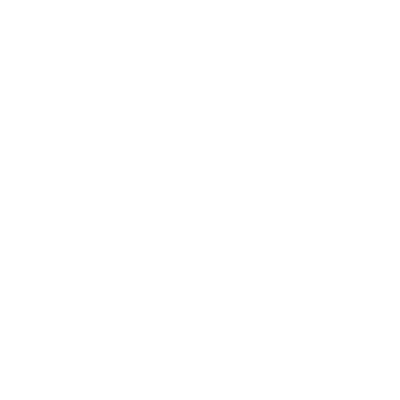

In [ ]:
np.ones((400,400,3), dtype=np.uint8) * 255

In [ ]:
# 이미지 생성 함수
def create_sample_image():
    # 흰색 배경 이미지 생성 (400*400 크기, 3채널 컬러)
    img = np.ones((400,400,3), dtype=np.uint8) * 255

    # 파란색 사각형 그리기 (왼쪽 위)
    cv2.rectangle(
        img,           # 그릴 이미지
        (50,50),       # 시작점(x,y)
        (150,150),     # 끝점 (x', y')
        (255, 0, 0),   # BGR 색상(파란색)
        -1             # 내부 채우기, 양수면 두께
    )

    # 초록색 원 그리기 오른쪽 위)
    cv2.circle(
        img,           # 그릴 이미지
        (300,100),     # 중심점
        50,            # 반지름(radius)
        (0, 255, 0),   # BGR 색상(초록색)
        -1             # 내부 채우기, 양수면 두께
    )

    # 빨간색 삼각형 그리기 (아래쪽)
    triangle_pts = np.array([[200,250],[150,350],[250,350]], dtype=np.int32)
    # 세 꼭지점
    cv2.fillPoly(
        img,
        [triangle_pts], # 다각형 점들(리스트로 감싸줘야 해요)
        (0, 0, 255)     # BGR 색상(빨간색)
    )

    # 텍스트 추가
    cv2.putText(
       img,
       'DoosanRobotics', # 표시할 텍스트
       (100,250),        # 텍스트 시작 위치(x,y)
       cv2.FONT_HERSHEY_SIMPLEX, # 폰트 종류
       1,                        # 폰트 크기
       (0,0,0),                  # 폰트 색상 (검은색)
       2,                        # 폰트 두께
       cv2.LINE_AA               # 선 종류 (anti-aliasing>> 안티앨리어싱 부드러운 선)

   )
    return img # 생성된 이미지 반환

In [ ]:
# def create_sample_image():
#     img = np.ones((400,400,3), dtype=np.uint8) * 255

#     cv2.rectangle(
#         img,           # 그릴 이미지
#         (50,50),       # 시작점(x,y)
#         (150,150),     # 끝점 (x', y')
#         (255, 0, 0),   # BGR 색상(파란색)
#         -1             # 내부 채우기, 양수면 두께
#     )

#     # 초록색 원 그리기 오른쪽 위)
#     cv2.circle(
#         img,           # 그릴 이미지
#         (300,100),     # 중심점
#         50,            # 반지름(radius)
#         (0, 255, 0),   # BGR 색상(초록색)
#         -1             # 내부 채우기, 양수면 두께
#     )

#     cv2.rectangle(
#         img,
#         (50, 50),
#         (150, 150),
#         (255, 0,0),
#         -1
#     )

#     # 빨간색 삼각형 그리기 (아래쪽)
#     triangle_pts = np.array([[200,250],[150,350],[250,350]], dtype=np.int32)
#     # 세 꼭지점
#     cv2.fillPoly(
#         img,
#         [triangle_pts], # 다각형 점들(리스트로 감싸줘야 해요)
#         (0, 0, 255)     # BGR 색상(빨간색)
#     )

#     # 텍스트 추가
#     cv2.putText(
#        img,
#        'DoosanRobotics', # 표시할 텍스트
#        (100,250),        # 텍스트 시작 위치(x,y)
#        cv2.FONT_HERSHEY_SIMPLEX, # 폰트 종류
#        1,                        # 폰트 크기
#        (0,0,0),                  # 폰트 색상 (검은색)
#        2,                        # 폰트 두께
#        cv2.LINE_AA               # 선 종류 (anti-aliasing>> 안티앨리어싱 부드러운 선)

#    )
#     return img # 생성된 이미지 반환

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
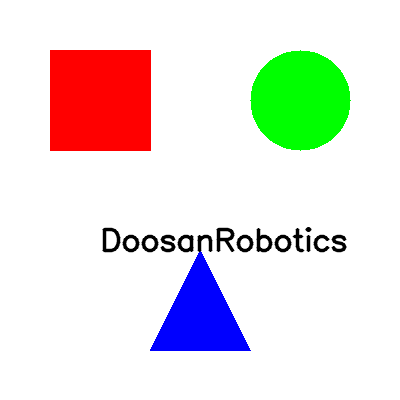

In [ ]:
# 샘플 이미지 생성
sample_img = create_sample_image()
sample_img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
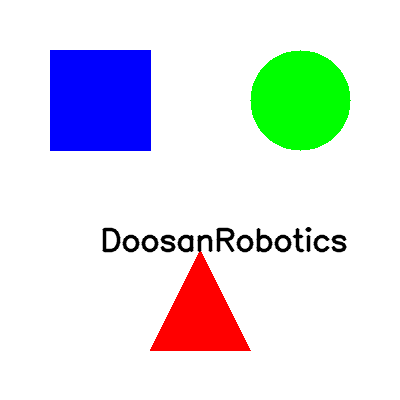

In [ ]:
# BGR > RGB 변환
cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

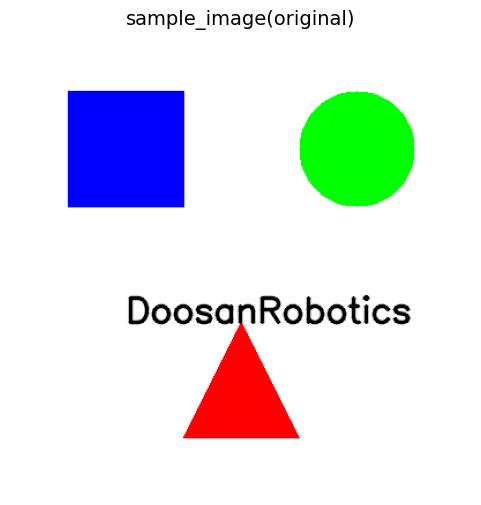

In [ ]:
# BGR > RGB 변환
sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# 이미지 표시
plt.figure(figsize=(6,6))
plt.imshow(sample_img_rgb)
plt.title('sample_image(original)', fontsize=14)
plt.axis('off')
plt.show()

In [ ]:
sample_img.shape

(400, 400, 3)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
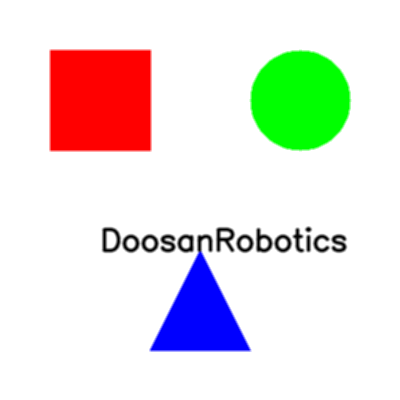

In [ ]:
cv2.blur(
    sample_img,
    (3,3)    # 커널크기(가로, 세로), 클수록 더 흐림
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
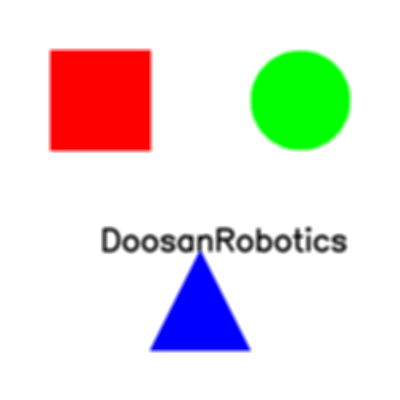

In [ ]:
cv2.blur(
    sample_img,
    (5,5)    # 커널크기(가로, 세로), 클수록 더 흐림
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
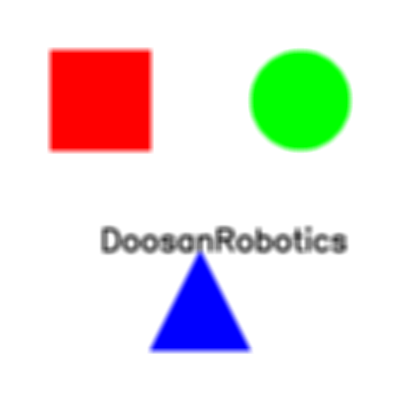

In [ ]:
cv2.blur(
    sample_img,
    (7,7)    # 커널크기(가로, 세로), 클수록 더 흐림
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
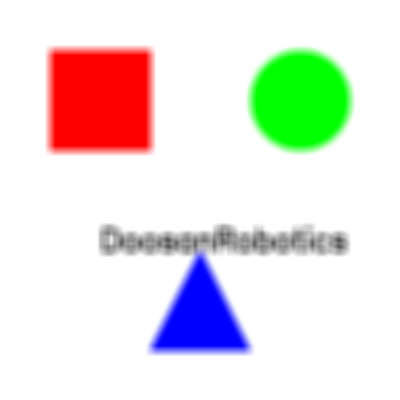

In [ ]:
# 필터(filter)실습

# 평균 블러(average blur)
# 커널 크기만큼 픽셀들을 평균값으로 대체

blur_avg = cv2.blur(
    sample_img,
    (11,11)    # 커널크기(가로, 세로), 클수록 더 흐림
)
blur_avg

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
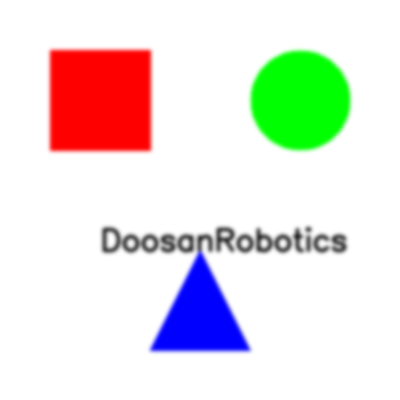

In [ ]:
# 가우시안 필터(Gaussian Blur)
# 평균, 중심에 가까울 수록 더 큰 가중치(가중평균)주는 블러

blur_gaussian = cv2.GaussianBlur(
    sample_img,
    (11,11),    # 커널크기(가로, 세로), 클수록 더 흐림
    0           # sigmaX(표준편차) 0: 자동계산
)
blur_gaussian

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
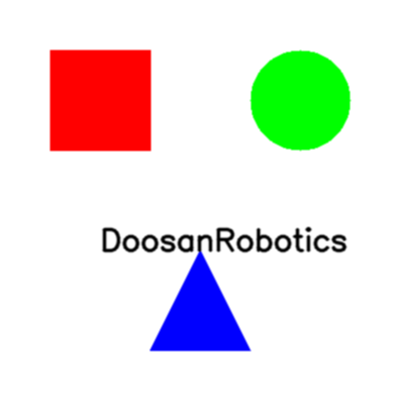

In [ ]:
cv2.GaussianBlur(
    sample_img,
    (3,3),
    0
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
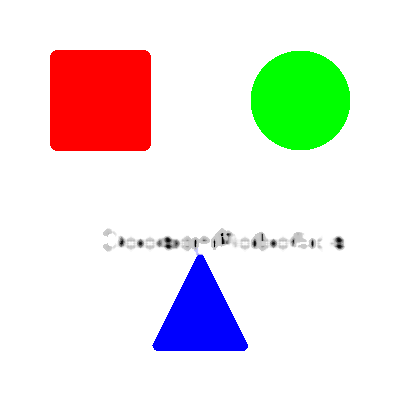

In [ ]:
# 중간값 블러(medianBlur)

blur_median = cv2.medianBlur(
    sample_img,
    11    # 반드시 홀수여야 함
)
blur_median

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
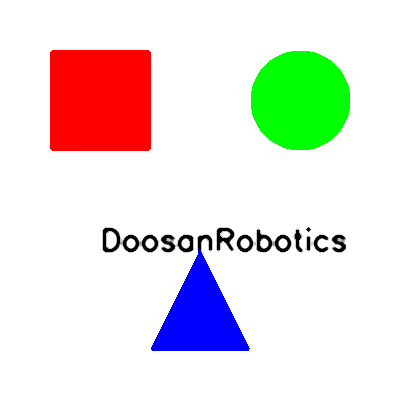

In [ ]:
md_blur = cv2.medianBlur(
    sample_img,
    5
)
md_blur

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
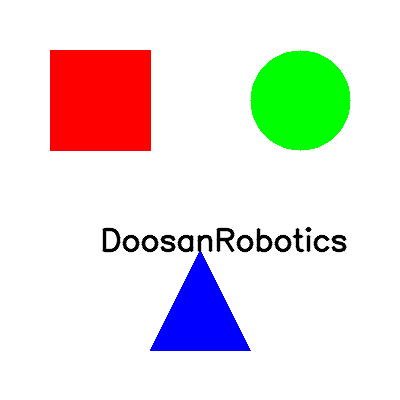

In [ ]:
# 양방향 필터(bilateral Filter)
# 경계선 보존, 부드럽게 만들어줘요. (가장 최고급 필터)

blur_bilateral = cv2.bilateralFilter(
    sample_img,
    15,      # 픽셀 이웃 직경
    80,      # 색상 공간의 표준편차 (클수록 더 많은 색상 표현 가능)
    80       # 좌표 공간의 표준편차 (클수록 더 넓은 영역 고려)
)
blur_bilateral

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
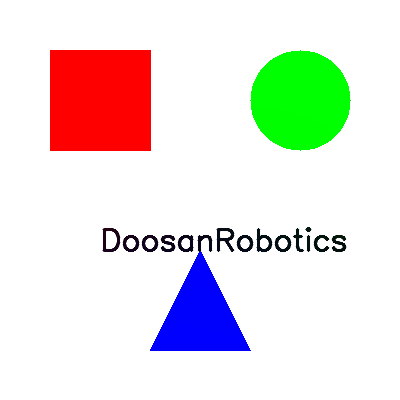

In [ ]:
blur_bil = cv2.bilateralFilter(
    sample_img,
    -1, # 직경을 -1로 주면 >> sigmaSpace 가 작동 자동계산(성능 최적화)
    100,
    100
)
blur_bil

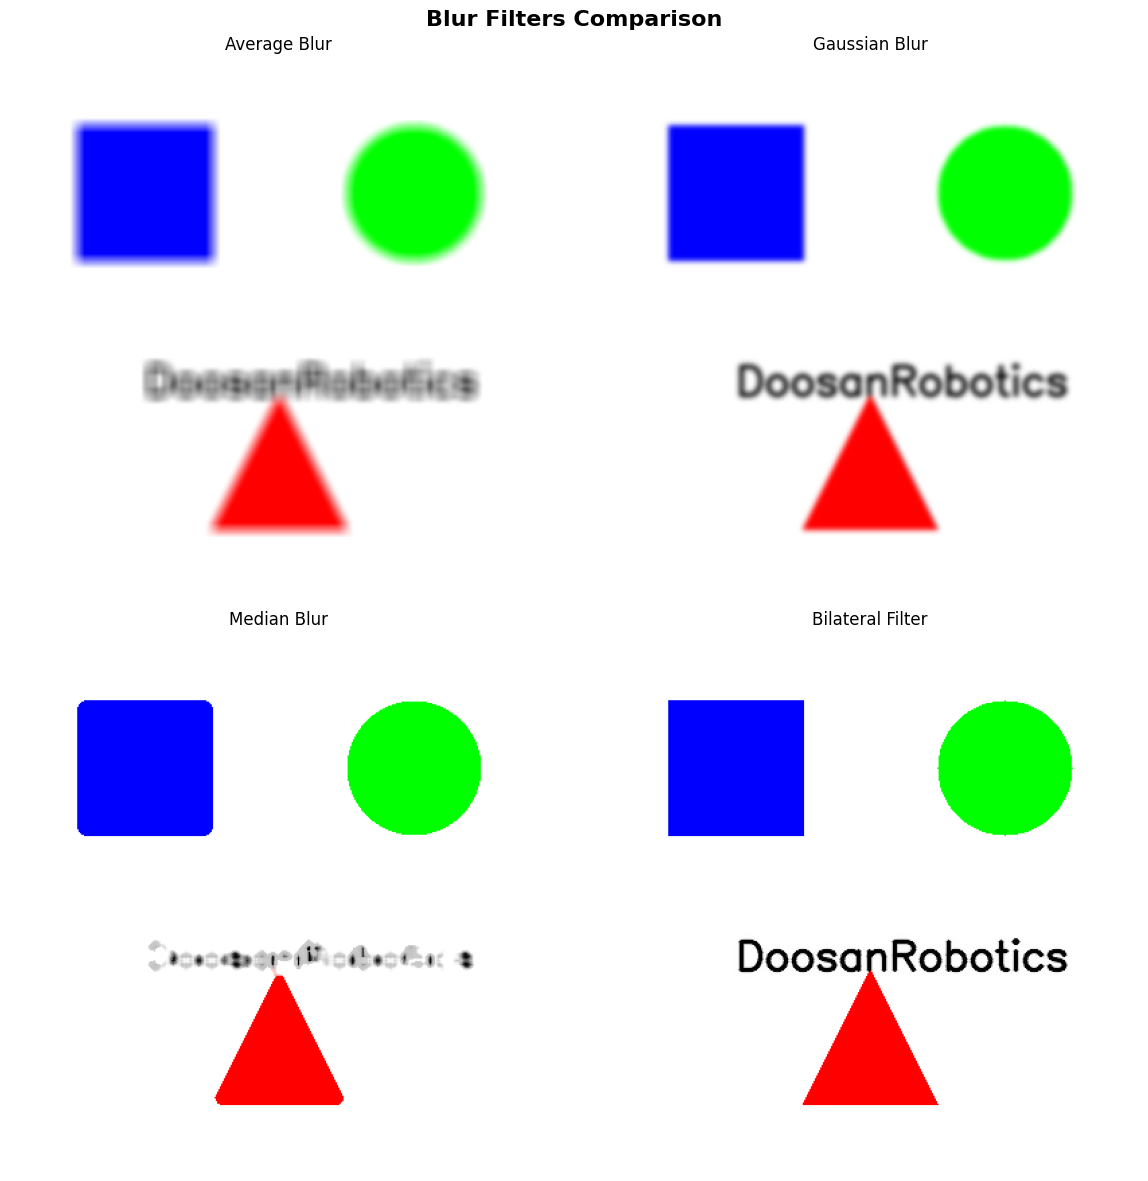

In [ ]:
# 4개의 결과를 2x2 그리드로 표시
fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2행 2열 서브플롯 생성
fig.suptitle('Blur Filters Comparison', fontsize=16, fontweight='bold')  # 전체 제목

# 각 필터 결과를 RGB로 변환하여 표시
images = [blur_avg, blur_gaussian, blur_median, blur_bilateral]  # 이미지 리스트
titles = ['Average Blur', 'Gaussian Blur', 'Median Blur', 'Bilateral Filter']  # 제목 리스트

for idx, (ax, img, title) in enumerate(zip(axes.flat, images, titles)):
    # axes.flat : 이미지가 그려질 위치(grid 에서 )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR >> RGB
    ax.imshow(img_rgb)  # 이미지 표시
    ax.set_title(title, fontsize=12)  # 제목 설정
    ax.axis('off')  # 축 숨기기

plt.tight_layout()  # 서브플롯 간 간격 조정
plt.show()  # 화면에 표시

경계선 검출(엣지 필터)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
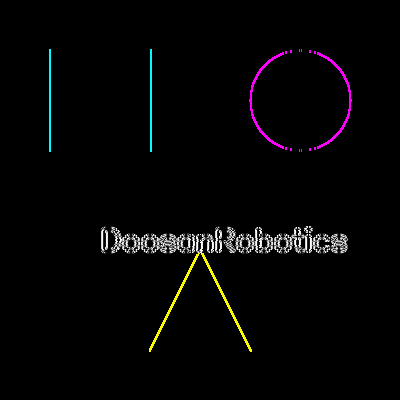

In [ ]:
sobel_x = cv2.Sobel(
        sample_img,
        cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
        1,          # x방향 미분 차수 (1 = 1차 미분)
        0,          # y방향 미분 차수 (0 = 미분 안 함)
        ksize=3     # 커널 사이즈 (1,3,5,7,.... 홀수에서 하나 선택)
    )

sobel_x = np.uint8(np.absolute(sobel_x))
# 절대값 취한 뒤, uint8로 변환
sobel_x

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
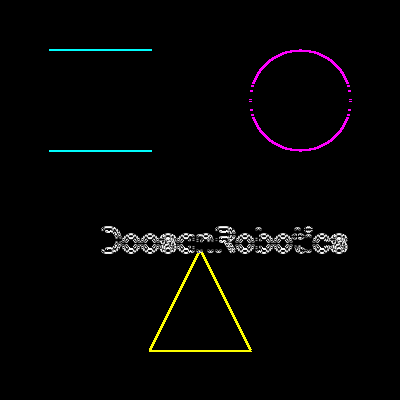

In [ ]:
sobel_y = cv2.Sobel(
        sample_img,
        cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
        0,          # x방향 미분 차수 (0 = 미분 안 함)
        1,          # y방향 미분 차수 (1 = 1차 미분)
        ksize=3     # 커널 사이즈 (1,3,5,7,.... 홀수에서 하나 선택)
    )

sobel_y = np.uint8(np.absolute(sobel_y))
# 절대값 취한 뒤, uint8로 변환
sobel_y

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
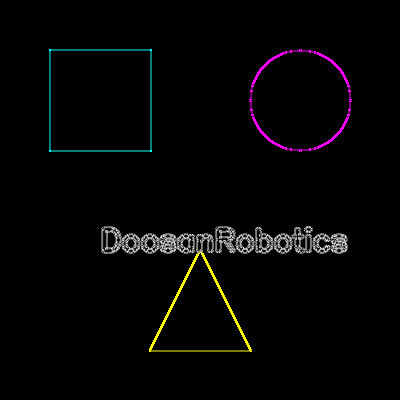

In [ ]:
# 엣지 검출 필터 적용하기

# 소벨 필터 : 가로/세로 방향 엣지 검출
# 경계선 찾아주는 필터 (이미지에서 밝기값이 얼마나 급격하게 변했는지 즉 기울기 계산함)
# 가로방향 엣지 검출 (세로 선 강조)

sobel_x = cv2.Sobel(
        sample_img,
        cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
        1,          # x방향 미분 차수 (1 = 1차 미분)
        0,          # y방향 미분 차수 (0 = 미분 안 함)
        ksize=3     # 커널 사이즈 (1,3,5,7,.... 홀수에서 하나 선택)
    )

sobel_x = np.uint8(np.absolute(sobel_x))
# 절대값 취한 뒤, uint8로 변환
# 절대값 취하는 이유
# 밝음(255) >> 어두움(0) 음수 변화 / 어두움(0) >> 밝음(255) 양수 변화
# >> 어라? 둘 다 경계선(edge) 부호가 반대, 크기만 나타내야 하니까 절대값 씌우자

# sobel_x

# 세로방향 엣지 검출 (가로 선 강조)
# y방향 1차 미분함 >> 가로로 뻗은 선 검출 (픽셀값이 세로방향으로 변하면 반응함)
sobel_y = cv2.Sobel(
        sample_img,
        cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
        0,          # x방향 미분 차수 (0 = 미분 안 함)
        1,          # y방향 미분 차수 (1 = 1차 미분)
        ksize=3     # 커널 사이즈 (1,3,5,7,.... 홀수에서 하나 선택)
    )

sobel_y = np.uint8(np.absolute(sobel_y))
# 절대값 취한 뒤, uint8로 변환

# sobel_y

# 변화가 큰 경우 (-) 존재 가능
# 예를 들어 0(어두운 밤) >> 255(밝은 곳) 엄청나게 큰 양수 변환
# 255 >> 0 엄청난 큰 음수 변화
# 그래서, 절대값 씌우는 거예요
# 근데 왜 실수 했다가 uint (부호없는 정수)로 바꿀까요?
# 부호없다며>> 음수 저장 안됨

# 가로/세로 방향 결합한 필터
sobel_combined = cv2.addWeighted(sobel_x, 0.5,  # 1번째 이미지와 가중치
                    sobel_y, 0.5,               # 2번째 이미지와 가중치
                    0)                          # 추가 상수 (이미지 밝기 조절)
sobel_combined

In [ ]:
# sobel_x = cv2.Sobel(
#         sample_img,
#         cv2.CV_64F,
#         1,
#         0,
#         ksize=3
#     )

# sobel_x = np.uint8(np.absolute(sobel_x))

# sobel_y = cv2.Sobel(
#         sample_img,
#         cv2.CV_64F,
#         0,
#         1,
#         ksize=3
#     )

# sobel_y = np.uint8(np.absolute(sobel_y))

# sobel_combined = cv2.addWeighted(sobel_x, 0.5,
#                     sobel_y, 0.5,
#                     0)
# sobel_combined

array([[[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       ...,

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]]], dtype=uint8)
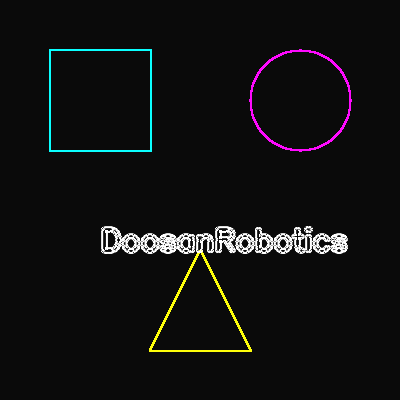

In [ ]:
sobel_combined = cv2.addWeighted(sobel_x, 1,  # 1번째 이미지와 가중치
                    sobel_y, 1,               # 2번째 이미지와 가중치
                    10)                       # 추가 상수 (이미지 밝기 조절)
sobel_combined

# 이지 밝기 추가 상수 비추 : 노이즈도 같이 증가(가중평균시 0.5 선호 원리: 평균의 원리 추종)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
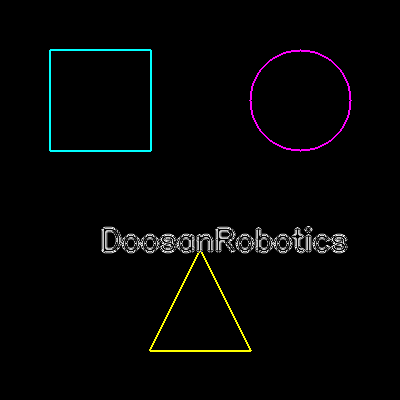

In [ ]:
# 라플라시안 필터(Laplacian Filter)
# 2차 미분 (곡률, 변환점) >> 모든 방향 엣지 검출

laplacian = cv2.Laplacian(
    sample_img,
    cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
)

laplacian = np.uint8(np.absolute(laplacian))
laplacian

캐니 원리 (3단계)
- 가우시안 블러: 노이즈 제거
- gradient 계산: 픽셀 변화 강도 계산
- NMS(Non-maximum suppresion) 계산: 가장 강한 경계선만 선택

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
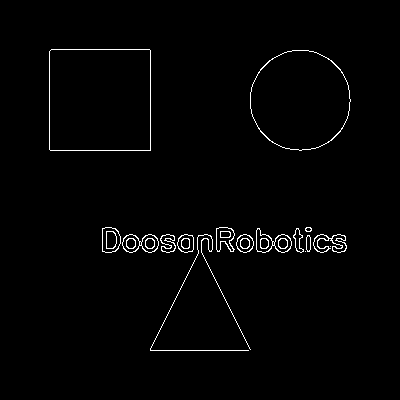

In [ ]:
# 캐니 엣지(Canny) : 가장 정밀한 엣지 검출
# 1단계: 먼저 그레이스케일(흑백) 변환
gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)

# 2단계: 엣지 검출 함수 적용
canny = cv2.Canny(
    gray,  # 그레이스케일로 변환된 이미지(케니는 흑백만 좋아해: 흑백만 지원)
    50,    # 최소 임계값(이보다 낮으면 엣지 아님)
    150    # 최대 임계값(이보다 높으면 확실한 엣지)
)

# 임계값 설정이 가장 중요
# 최대 임계값(이보다 높으면 확실한 엣지)
# >> 이미지에서 밝기 변화량(기울기)
# >> 여기서 150 설정했다는 것은 150이상은 픽셀은 무조건 강한 엣지로 간주
# >> 최종 결과에 포함
# 최소 임계값(이보다 낮으면 엣지 아님)
# >> 여기서 50 설정했다는 것은 50 미만은 무조건 엣지가 아니라고 간주 >> 버려
# 사이 구간(50-150) >> 약한 엣지 후보
# >> 강한 엣지(150 이상) 연결되어 있을 때만 최종적으로 엣지로 인정
# >> 연결 안되어 있으면 >> 버려

canny

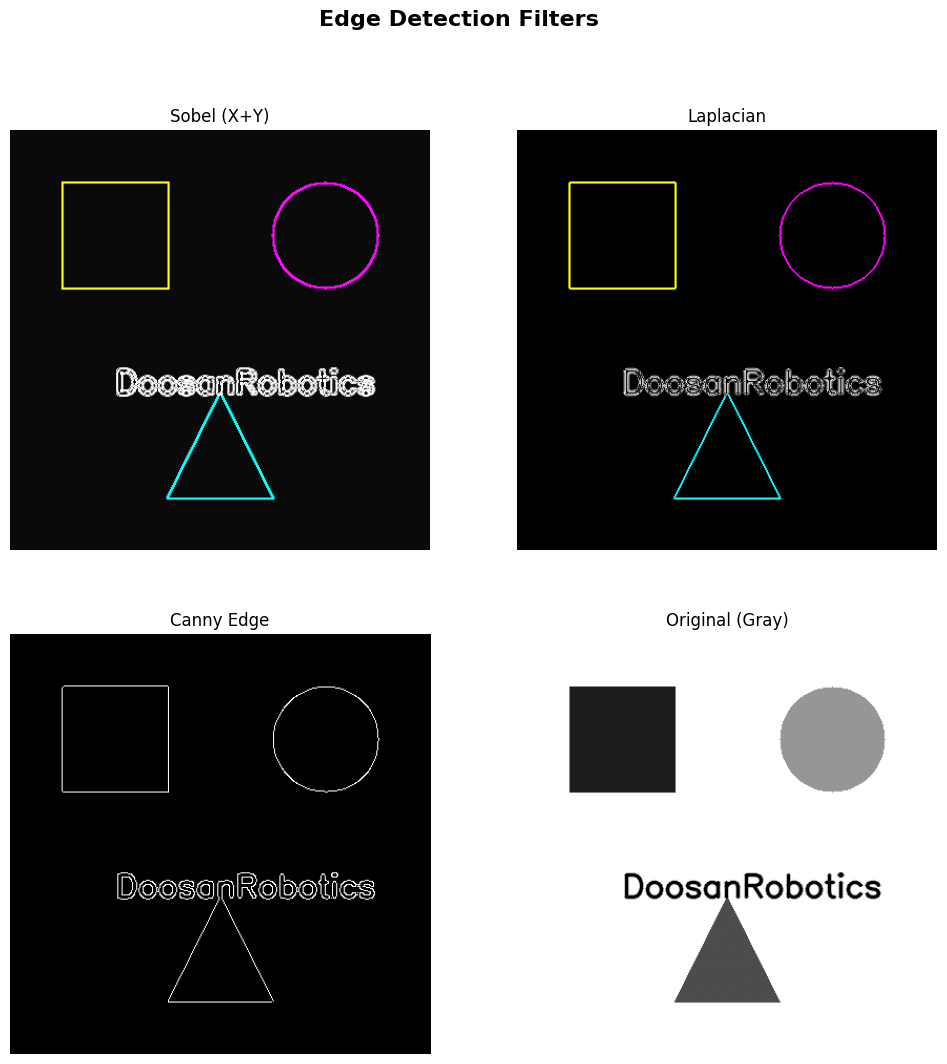

In [ ]:
# 4개의 결과를 2x2 그리드로 표시
fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2행 2열 서브플롯
fig.suptitle('Edge Detection Filters', fontsize=16, fontweight='bold')  # 전체 제목

# 결과 표시
edge_images = [sobel_combined, laplacian, canny, gray]  # 이미지 리스트
edge_titles = ['Sobel (X+Y)', 'Laplacian', 'Canny Edge', 'Original (Gray)']  # 제목 리스트

for idx, (ax, img, title) in enumerate(zip(axes.flat, edge_images, edge_titles)):
    # 캐니와 그레이는 이미 흑백이므로 cmap='gray' 사용
    if idx >= 2:  # 캐니와 원본 그레이
        ax.imshow(img, cmap='gray')  # 흑백으로 표시
    else:  # 소벨과 라플라시안
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR을 RGB로 변환
        ax.imshow(img_rgb)  # 컬러로 표시

    ax.set_title(title, fontsize=12)  # 제목 설정
    ax.axis('off')  # 축 숨기기

In [ ]:
# 회전, 크기 조절
# 다양한 각도 크기 이미지 회전하기
# ex) shape(400, 400, 3)
height, width = sample_img.shape[:2]

center = (width//2, height//2)
# 이미지 중심점 계산 (// 몫, 정수 나눗셈 )

In [ ]:
# 45도 회전
matrix45 = cv2.getRotationMatrix2D(
    center, # 회전 중심점
    45,     # 회전 각도(양수: 반시계방향) 양반음시(양수 반시계 음수 시계)
    1.0     # 스케일(1.0 원본 크기 유지)
)

matrix45

array([[  0.70710678,   0.70710678, -82.84271247],
       [ -0.70710678,   0.70710678, 200.        ]])

In [ ]:
matrix45.shape

(2, 3)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
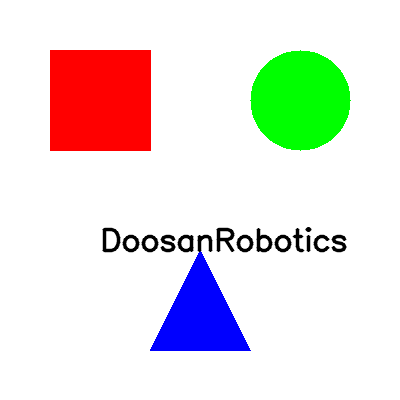

In [ ]:
sample_img

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
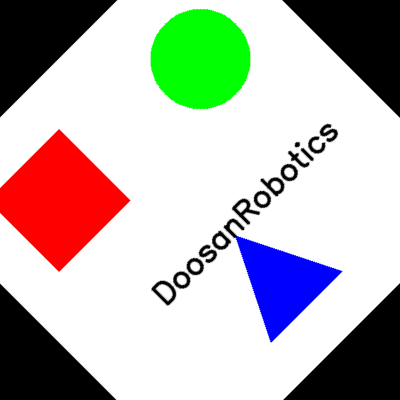

In [ ]:
rotated45 = cv2.warpAffine(
    sample_img,      # 원본이미지
    matrix45,        # 변환 행렬
    (width, height)  # 출력 이미지 크기(크기유지)
)

rotated45

In [ ]:
# height, width = sample_img.shape[:2]

# center = (width//2, height//2)

# # 45도 회전
# matrix45 = cv2.getRotationMatrix2D(
#     center, # 회전 중심점
#     45,     # 회전 각도(양수: 반시계방향) 양반음시(양수 반시계 음수 시계)
#     1.0     # 스케일(1.0 원본 크기 유지)
# )

# rotated45 = cv2.warpAffine(
#     sample_img,      # 원본이미지
#     matrix45,        # 변환 행렬
#     (width, height)  # 출력 이미지 크기(크기유지)
# )

# rotated45

In [ ]:
# 90도 회전
matrix90 = cv2.getRotationMatrix2D(
    center, # 회전 중심점
    90,     # 회전 각도(양수: 반시계방향) 양반음시(양수 반시계 음수 시계)
    1.0     # 스케일(1.0 원본 크기 유지)
)

matrix90

array([[ 6.12323400e-17,  1.00000000e+00, -2.84217094e-14],
       [-1.00000000e+00,  6.12323400e-17,  4.00000000e+02]])

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
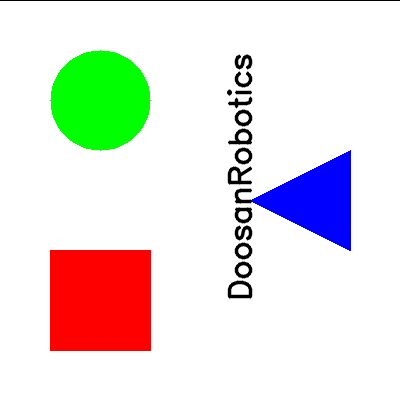

In [ ]:
rotated90 = cv2.warpAffine(
    sample_img,      # 원본이미지
    matrix90,        # 변환 행렬
    (width, height)  # 출력 이미지 크기(크기유지)
)

rotated90

In [ ]:
# 45도 회전 + 0.5 배 축소
# 45도 회전
matrix45_half = cv2.getRotationMatrix2D(
    center, # 회전 중심점
    45,     # 회전 각도(양수: 반시계방향) 양반음시(양수 반시계 음수 시계)
    0.5     # 스케일(1.0 원본 크기 유지)
)

matrix45_half

array([[  0.35355339,   0.35355339,  58.57864376],
       [ -0.35355339,   0.35355339, 200.        ]])

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
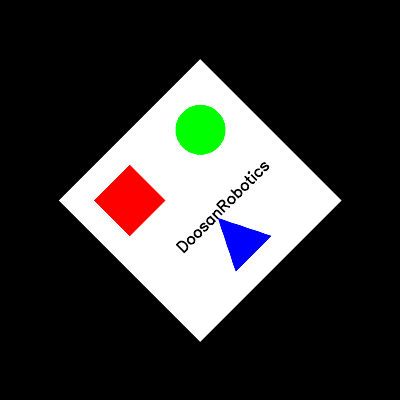

In [ ]:
rotated45_half = cv2.warpAffine(
    sample_img,      # 원본이미지
    matrix45_half,        # 변환 행렬
    (width, height)  # 출력 이미지 크기(크기유지)
)

rotated45_half

In [ ]:
# 30회전, 1.5배 확대

matrix30_large = cv2.getRotationMatrix2D(
    center, # 회전 중심점
    30,     # 회전 각도(양수: 반시계방향) 양반음시(양수 반시계 음수 시계)
    1.5     # 스케일
)

matrix30_large

array([[   1.29903811,    0.75      , -209.80762114],
       [  -0.75      ,    1.29903811,   90.19237886]])

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
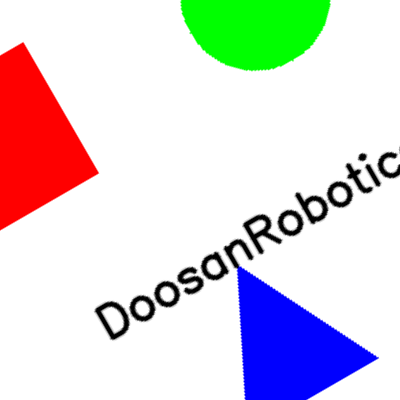

In [ ]:
rotated30_large = cv2.warpAffine(
    sample_img,      # 원본이미지
    matrix30_large,        # 변환 행렬
    (width, height)  # 출력 이미지 크기(크기유지)
)

rotated30_large

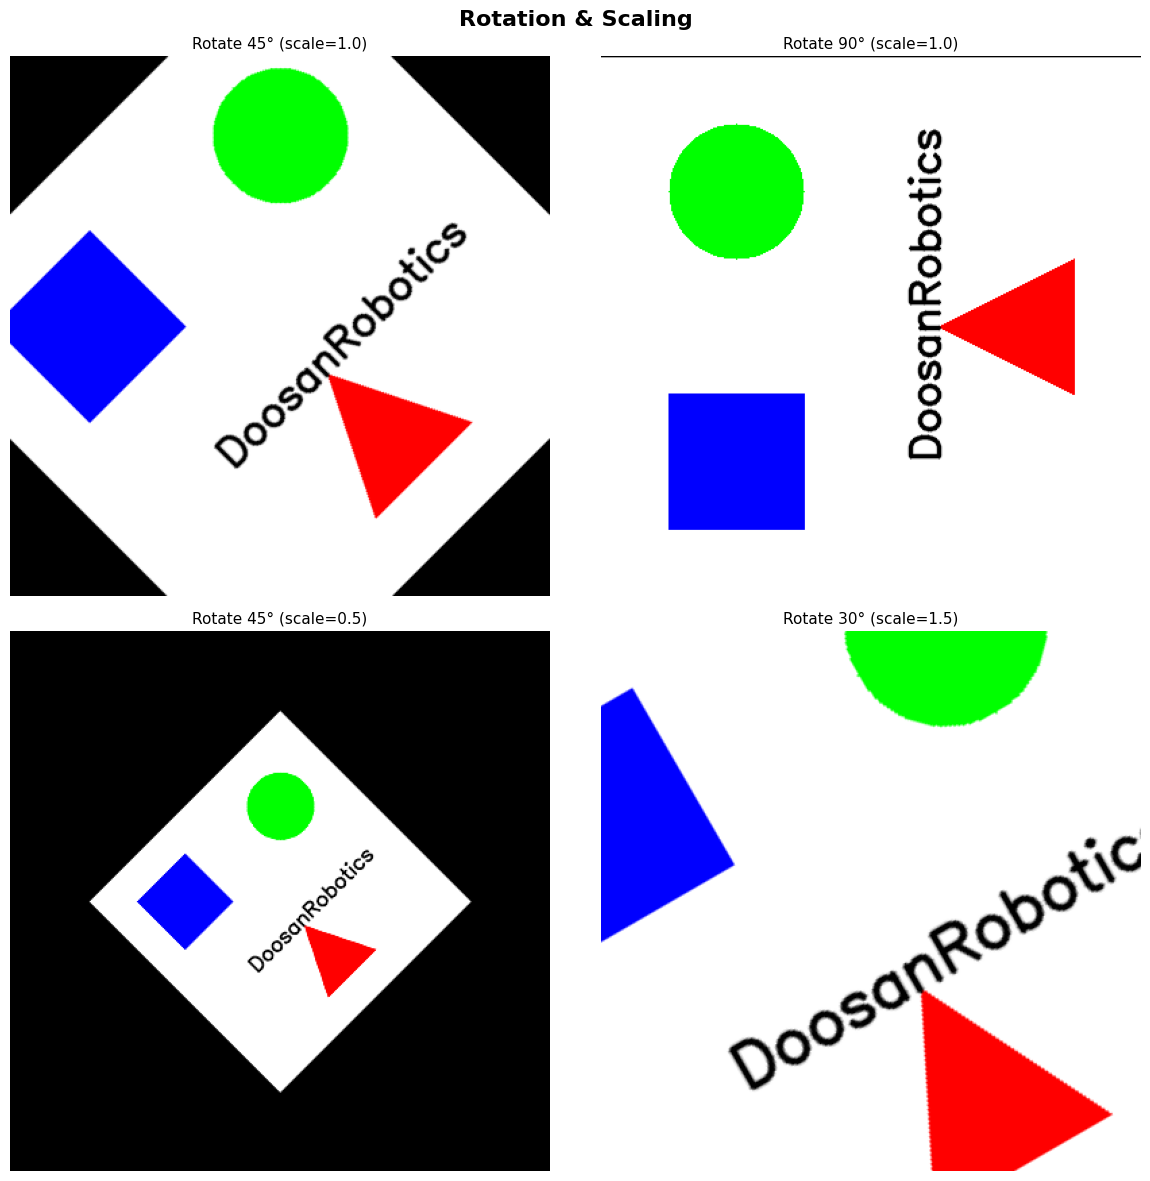

In [ ]:
# 결과를 2x2 그리드로 표시
fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2행 2열 서브플롯
fig.suptitle('Rotation & Scaling', fontsize=16, fontweight='bold')  # 전체 제목

# 회전 결과들
rotation_images = [rotated45, rotated90, rotated45_half, rotated30_large]  # 이미지 리스트
rotation_titles = [
    'Rotate 45° (scale=1.0)',  # 45도 회전
    'Rotate 90° (scale=1.0)',  # 90도 회전
    'Rotate 45° (scale=0.5)',  # 45도 회전 + 축소
    'Rotate 30° (scale=1.5)'   # 30도 회전 + 확대
]

# 각 subplot에 이미지 표시
for ax, img, title in zip(axes.flat, rotation_images, rotation_titles):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR을 RGB로 변환
    ax.imshow(img_rgb)  # 이미지 표시
    ax.set_title(title, fontsize=11)  # 제목 설정
    ax.axis('off')  # 축 숨기기

plt.tight_layout()  # 레이아웃 자동 조정
plt.show()  # 화면에 표시

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
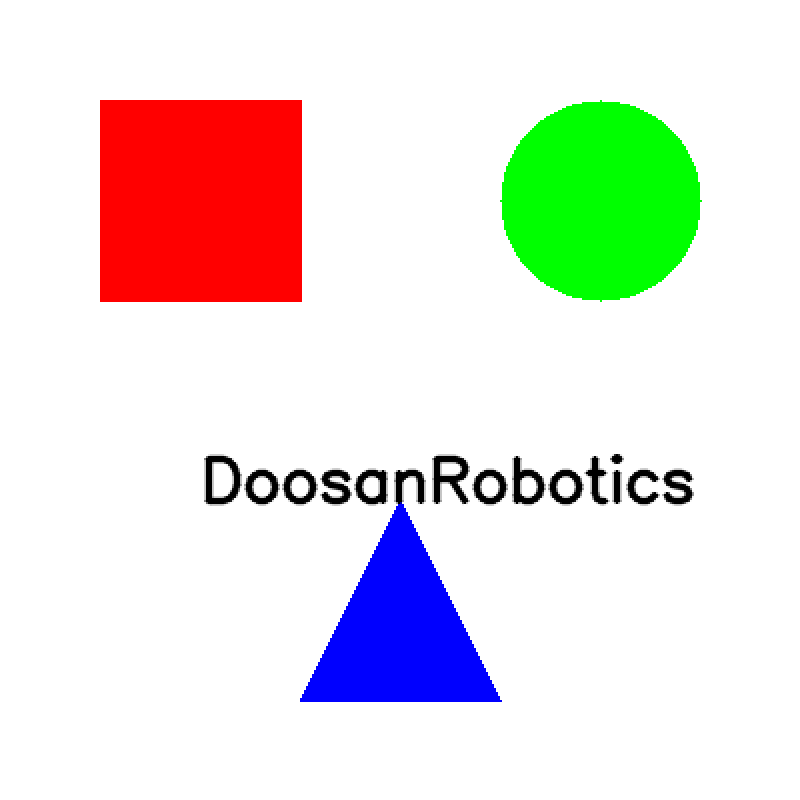

In [ ]:
# 보간법
# 원본 이미지 2배 확대

# 1) INTER_NEAREST
# >> 최근접 이웃 셀 값을 복사 (가장 빠름, 품질 낮음, 계단 현상)

resized_nearest = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_NEAREST
)

resized_nearest

In [ ]:
# resized_nearest = cv2.resize(
#     sample_img,
#     (width**2, height*2),
#     interpolation=cv2.inter_nearest
# )

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
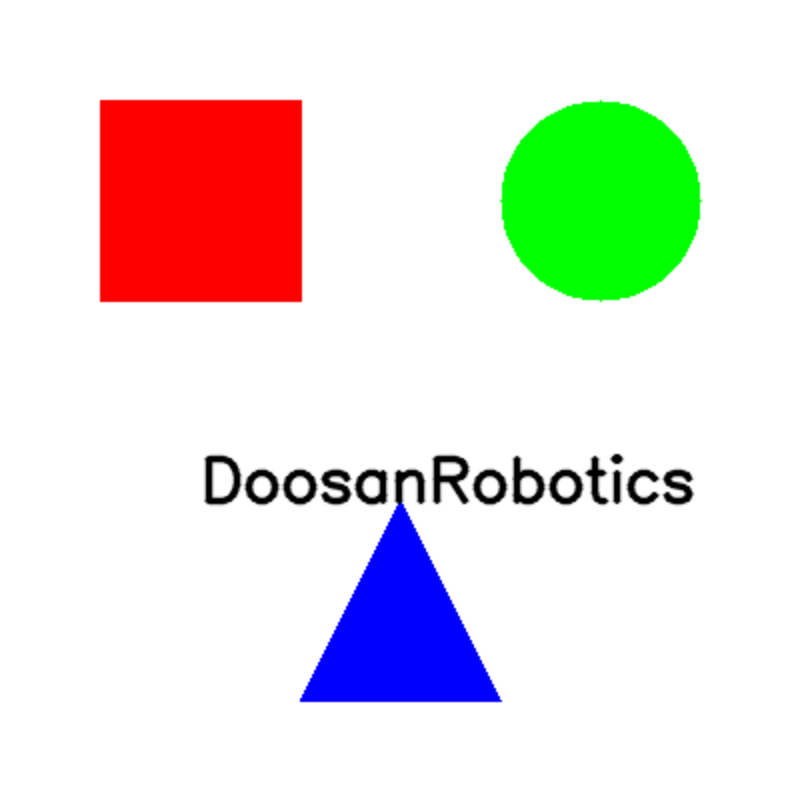

In [ ]:
# 2) INTER_LINEAR
# 기본값(default), 적당한 속도와 품질

resized_linear = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_LINEAR
)

resized_linear

In [ ]:
# resized_nearest = cv2.resize(
#     sample_img,
#     (width**2, height*2),
#     interpolation=cv2.INTER_LINEAR
# )

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
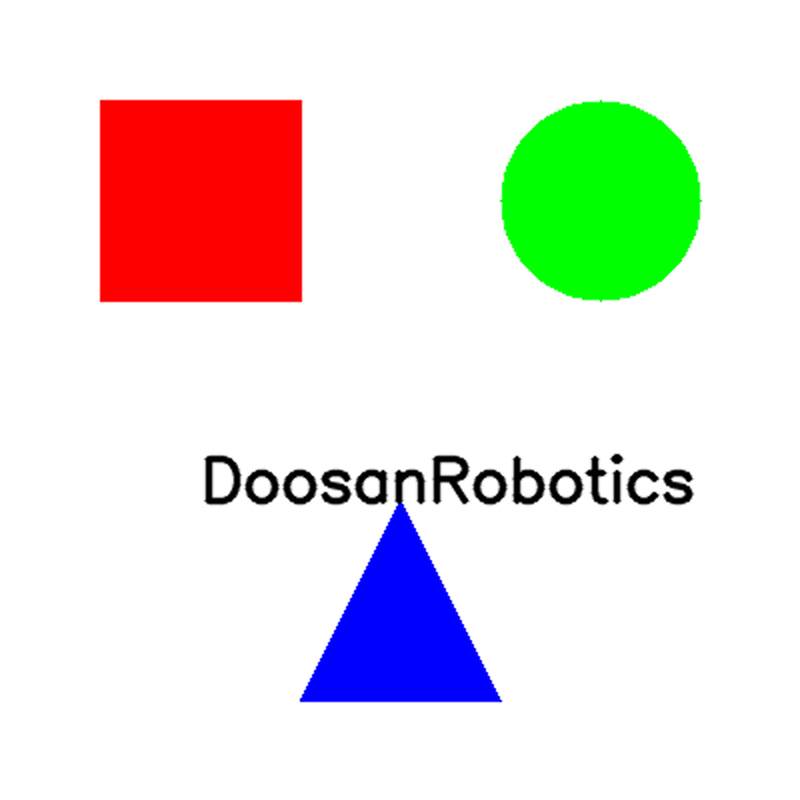

In [ ]:
# 3) INTER_CUBIC
# 4*4 (고품질), 약간 느림
resized_cubic = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_CUBIC
)

resized_cubic

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
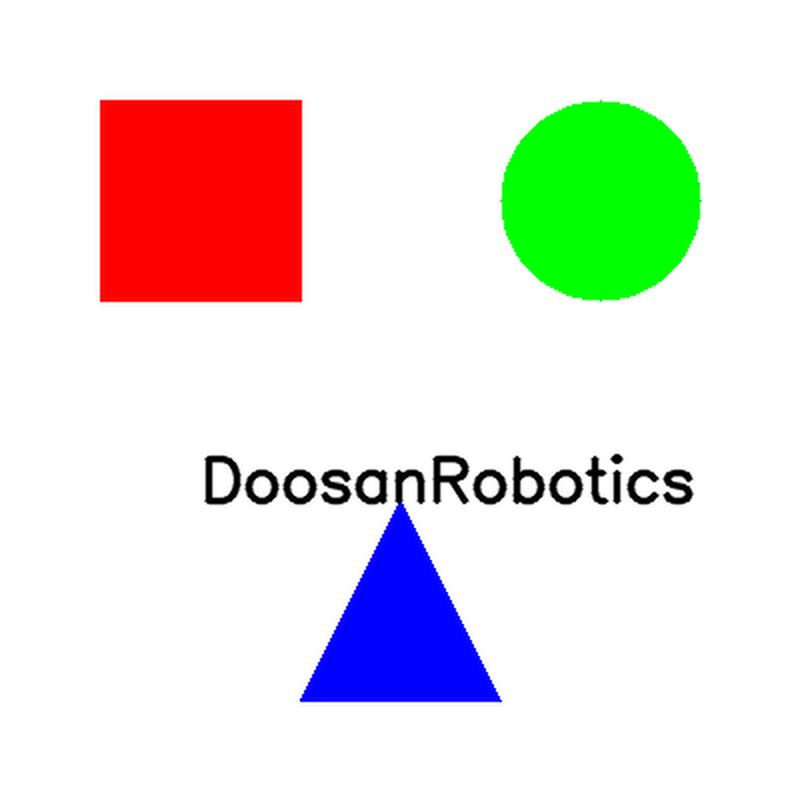

In [ ]:
# 4) INTER_LANCZOS4
# 8*8, 최고품질, 매우 느림
resized_lanczos = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_LANCZOS4
)

resized_lanczos


In [ ]:
# resized_lanczos = cv2.resize(
#     sample_img,
#     (width*2, height*2),
#     interpolation=cv2.INTER_LANCZOS4
# )

In [75]:
# 각 방법의 일부분을 확대해서 비교 (차이를 명확히 보기 위해)
# 중앙 부근의 80*80 픽셀 영역 추출
crop_y, crop_x = 280, 280  # 자를 위치 (확대된 이미지 기준)
crop_size = 80  # 자를 크기

cropped_nearest = resized_nearest[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
cropped_linear = resized_linear[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
cropped_cubic = resized_cubic[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
cropped_lanczos = resized_lanczos[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]

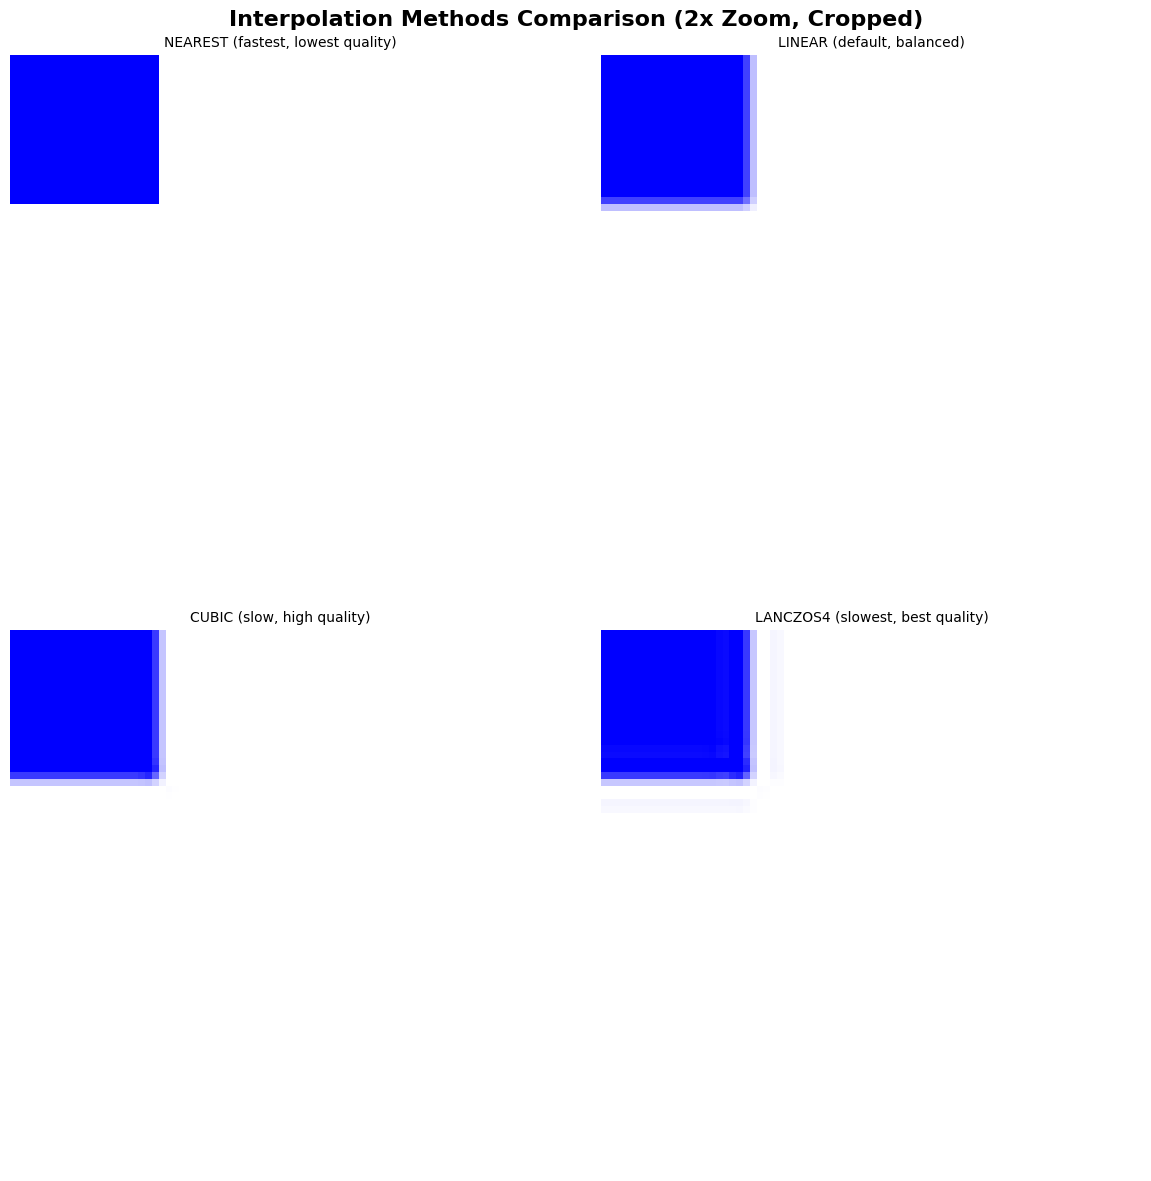

In [ ]:
# 결과를 2x2 그리드로 표시
fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2행 2열 서브플롯
fig.suptitle('Interpolation Methods Comparison (2x Zoom, Cropped)',
             fontsize=16, fontweight='bold')  # 전체 제목

# 확대 결과들 (일부 영역만)
interp_images = [cropped_nearest, cropped_linear, cropped_cubic, cropped_lanczos]
interp_titles = [
    'NEAREST (fastest, lowest quality)',  # 가장 빠름
    'LINEAR (default, balanced)',  # 기본값
    'CUBIC (slow, high quality)',  # 고품질
    'LANCZOS4 (slowest, best quality)'  # 최고품질
]

# 각 subplot에 이미지 표시
for ax, img, title in zip(axes.flat, interp_images, interp_titles):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR을 RGB로 변환
    ax.imshow(img_rgb)  # 이미지 표시
    ax.set_title(title, fontsize=10)  # 제목 설정
    ax.axis('off')  # 축 숨기기

plt.tight_layout()  # 레이아웃 자동 조정
plt.show()  # 화면에 표시

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
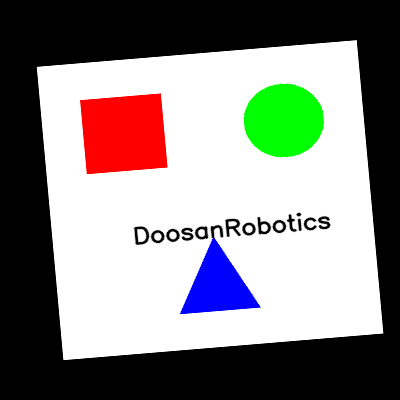

In [ ]:
# 아핀변환
# 3개 점을 이용한 변환

# 원본 이미지의 3개의 점 지정(삼각형 모서리)
src_pts = np.float32([
    [50,50],   # 왼쪽 위 점
    [350,50],  # 오른쪽 위
    [50,350]   # 왼쪽 아래 점
])

# 목표 위치의 3개 점 지정 (변환 후 위치))
dst_pts = np.float32([
    [80,100],   # 첫번째 점 이동 [50,50] >> [80,100] 오른쪽,아래 이동
    [320, 80],  # 두번째 점 이동 [350, 50] >> [320, 80] 왼쪽 아래 이동
    [100, 320]   # 세번째 점 이동 [50, 350] >> [100, 320] 오른쪽 위 이동
])

# 아핀변환 행렬 계산
affine_matrix = cv2.getAffineTransform(
    src_pts,    # 원본 3개의 점
    dst_pts     # 목표 3개의 점
)

# affine_matrix

# 3개의 점 대응 >> 2*3행렬이 생성
# array([[ 8.00000000e-01,  6.66666667e-02,  3.66666667e+01],
#        [-6.66666667e-02,  7.33333333e-01,  6.66666667e+01]])

# 아핀변환 적용
affine_result = cv2.warpAffine(
    sample_img,
    affine_matrix,
    (width, height)
)

affine_result

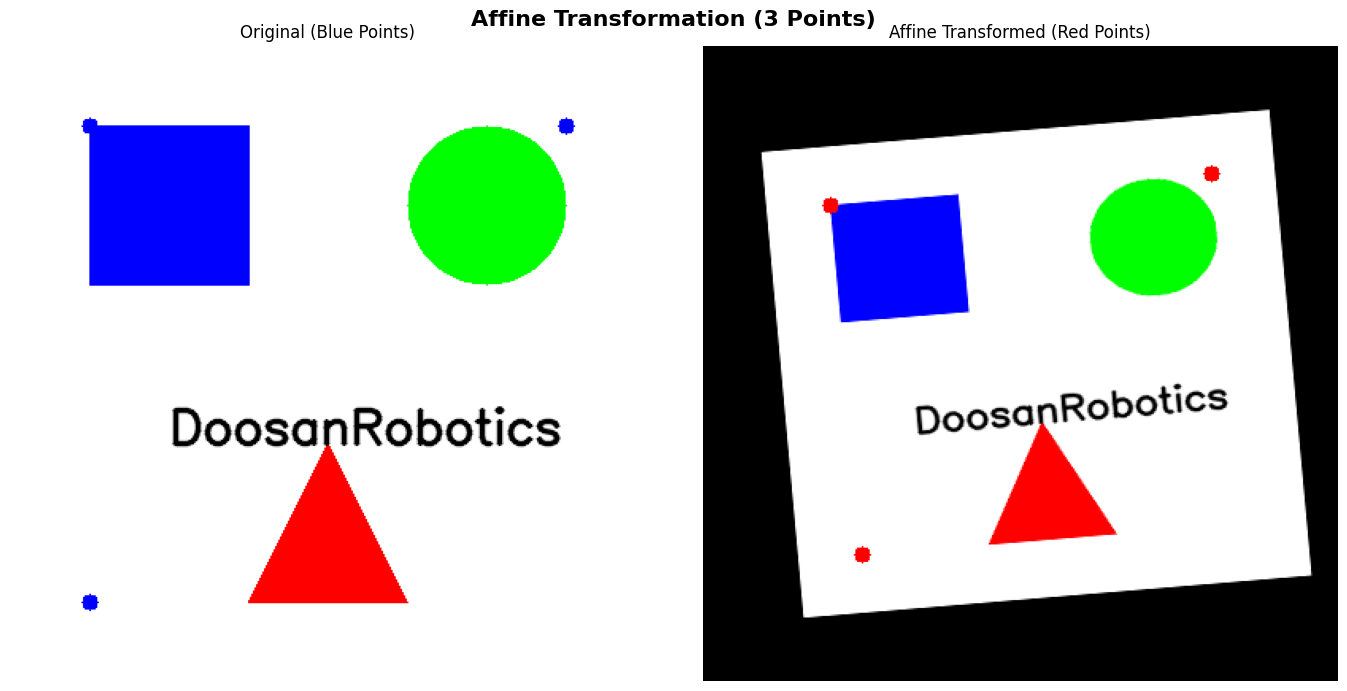

In [ ]:
# 원본 이미지에 점표시

original_with_pts = sample_img.copy()

for pt in src_pts:
    cv2.circle(
        original_with_pts,      # 그릴 이미지
        tuple(map(int, pt)),    # 점 위치
        5,                      # 반지름(radius)
        (255,0,0),              # BGR (파란색)
        -1                      # 채우기
    )

# 변환된 이미지에 점 표시
affine_with_pts = affine_result.copy()

for pt in dst_pts:
    cv2.circle(
        affine_with_pts,      # 그릴 이미지
        tuple(map(int, pt)),    # 점 위치
        5,                      # 반지름(radius)
        (0,0,255),              # BGR (빨간색))
        -1                      # 채우기
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 7))  # 1행 2열 서브플롯
fig.suptitle('Affine Transformation (3 Points)', fontsize=16, fontweight='bold')

# 원본 (파란 점)
axes[0].imshow(cv2.cvtColor(original_with_pts, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (Blue Points)', fontsize=12)
axes[0].axis('off')

# 변환 결과 (빨간 점)
axes[1].imshow(cv2.cvtColor(affine_with_pts, cv2.COLOR_BGR2RGB))
axes[1].set_title('Affine Transformed (Red Points)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
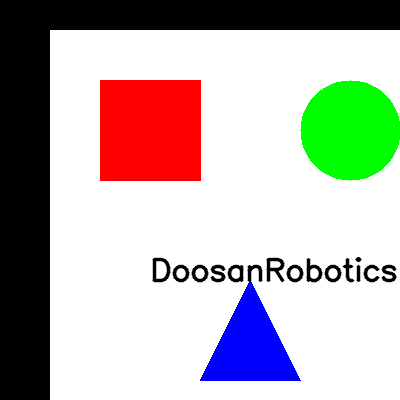

In [ ]:
# 수동으로 Affine 변환 행렬 만들기
# 행렬 구조 [[a, b, tx], [c, d, ty]]
# a, d : 크기 조절
# b, c : 기울이기 (shear)
# tx, ty: 이동

# 1)단순 이동 (translation)
translate_matrix = np.float32([
                    [1, 0, 50],  # x축: 크기 유지, 기울기 없음, 오른쪽 50px 이동
                    [0, 1, 30]   # y축 : 크기 유지, 기울기 없음, 아래 30px 이동
                ])

# translate_matrix

translated = cv2.warpAffine(sample_img, translate_matrix, (width, height))
translated

In [ ]:
# translate_matrix = np.float32([
#     [1,0,50],
#     [0,1,30]
# ])

# translated = cv2.warpAffine(sample_img, translate_matrix, (width, height))
# translated

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[175, 175, 175],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[104, 104, 104],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
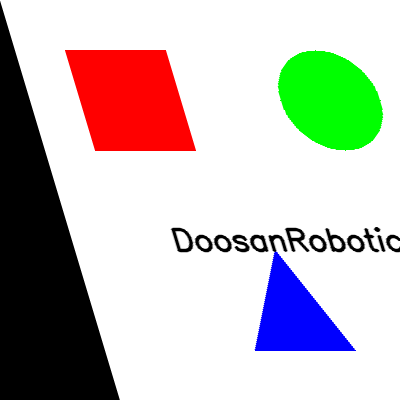

In [ ]:
# 2) 수평 기울이기(Horizontal Shear)

shear_x_matrix = np.float32([
                    [1, 0.3, 0],   # x축: 변화 없음
                    [0, 1, 0]      # y축: 크기 유지, x값에 따라서 y 이동(기울임), 이동 없음
                ])

# shear_x_matrix

sheared_x = cv2.warpAffine(sample_img, shear_x_matrix, (width, height))
sheared_x

array([[[255, 255, 255],
        [175, 175, 175],
        [104, 104, 104],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
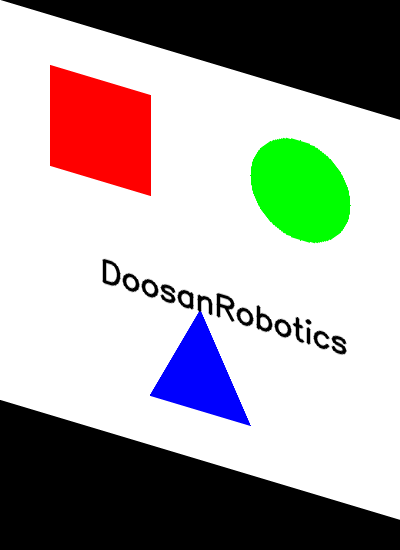

In [ ]:
# 3) 수직 기울이기(Vertical Shear)

shear_y_matrix = np.float32([
                    [1, 0, 0],
                    [0.3, 1, 0] # x값에 따라 y변화
                ])
# shear_y_matrix
sheared_y = cv2.warpAffine(sample_img, shear_y_matrix, (width, height + 150))
# 세로 크기 늘려서 잘리지 않게 보정
sheared_y


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
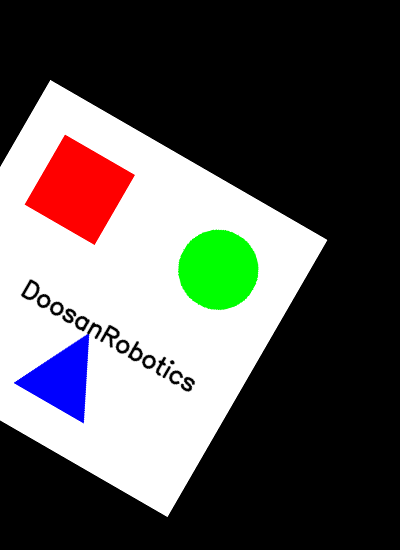

In [ ]:
# 복합 변환(회전 + 크기 + 이동)
# cos(30도) 0.866에 근사한 값 가짐, sin(30도) 0.5에 근사한 값 가짐
angle_rad = np.radians(30) # 30도를 radian으로 변환
# np.float64(0.5235987755982988)
cos_val = np.cos(angle_rad) # 코사인 값 계산
sin_val = np.sin(angle_rad) # 사인 값 계산
scale = 0.8   # 0.8배 축소

complex_matrix = np.float32([
    [cos_val * scale, -sin_val * scale, 50], # 회전, 축소, 이동
    [sin_val * scale, cos_val * scale, 80]

])

complex_transformed = cv2.warpAffine(sample_img, complex_matrix, (width, height + 150))
complex_transformed

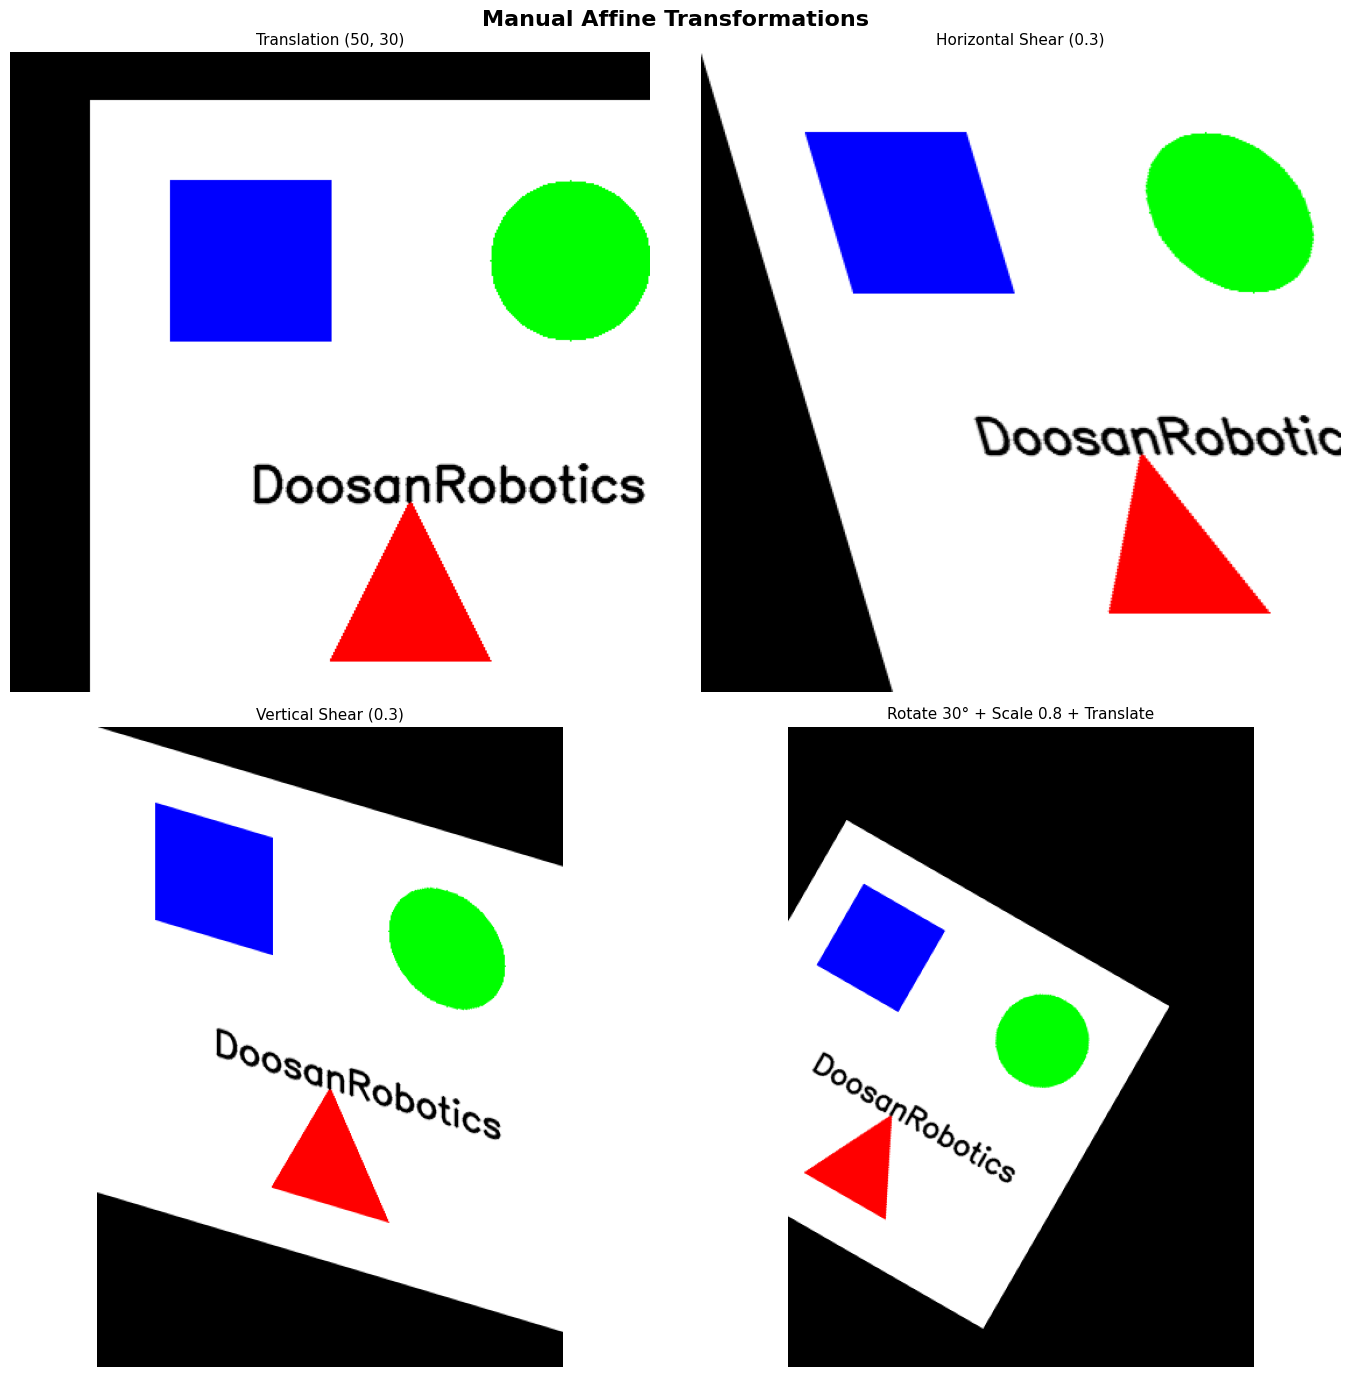

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('Manual Affine Transformations', fontsize=16, fontweight='bold')

# 변환 결과들
affine_results = [translated, sheared_x, sheared_y, complex_transformed]
affine_titles = [
    'Translation (50, 30)',  # 이동
    'Horizontal Shear (0.3)',  # 수평 기울임
    'Vertical Shear (0.3)',  # 수직 기울임
    'Rotate 30° + Scale 0.8 + Translate'  # 복합 변환
]

# 각 subplot에 이미지 표시
for ax, img, title in zip(axes.flat, affine_results, affine_titles):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Perspective 변환 : 4개의 점을 활용, 원근 변환
# 비스듬히 찍힌 사진을 정면으로 보정할 때 사용

# 원본 이미지의 4개 꼭지점 (사각형)
src_pts_persp = np.float32([
    [0, 0],           # 왼쪽 위
    [width-1, 0],     # 오른쪽 위
    [width-1, height-1],  # 오른쪽 아래
    [0, height-1]     # 왼쪽 아래
])

# 목표 위치 4개 점 (사다리꼴 모양으로 변환)
dst_pts_persp = np.float32([
    [50, 100],        # 왼쪽 위 → 오른쪽+아래 이동
    [width-50, 100],  # 오른쪽 위 → 왼쪽+아래 이동
    [width-20, height-50],  # 오른쪽 아래 → 왼쪽+위 이동
    [20, height-50]   # 왼쪽 아래 → 오른쪽+위 이동
])
# 결과: 위쪽이 좁고 아래쪽이 넓은 사다리꼴 (원근감)

# Perspective 변환 행렬 계산 ( 3*3 행렬 )
perspective_matrix = cv2.getPerspectiveTransform(
    src_pts_persp,  # 원본 4점
    dst_pts_persp   # 목표 4점
)

# print(perspective_matrix)


perspective_result = cv2.warpPerspective(
    sample_img,
    perspective_matrix, # 3*3 변환행렬
    (width, height),    # 출력크기
    borderValue=(200,200,200) # 빈 공간을 회색으로 채움
)

# perspective_result



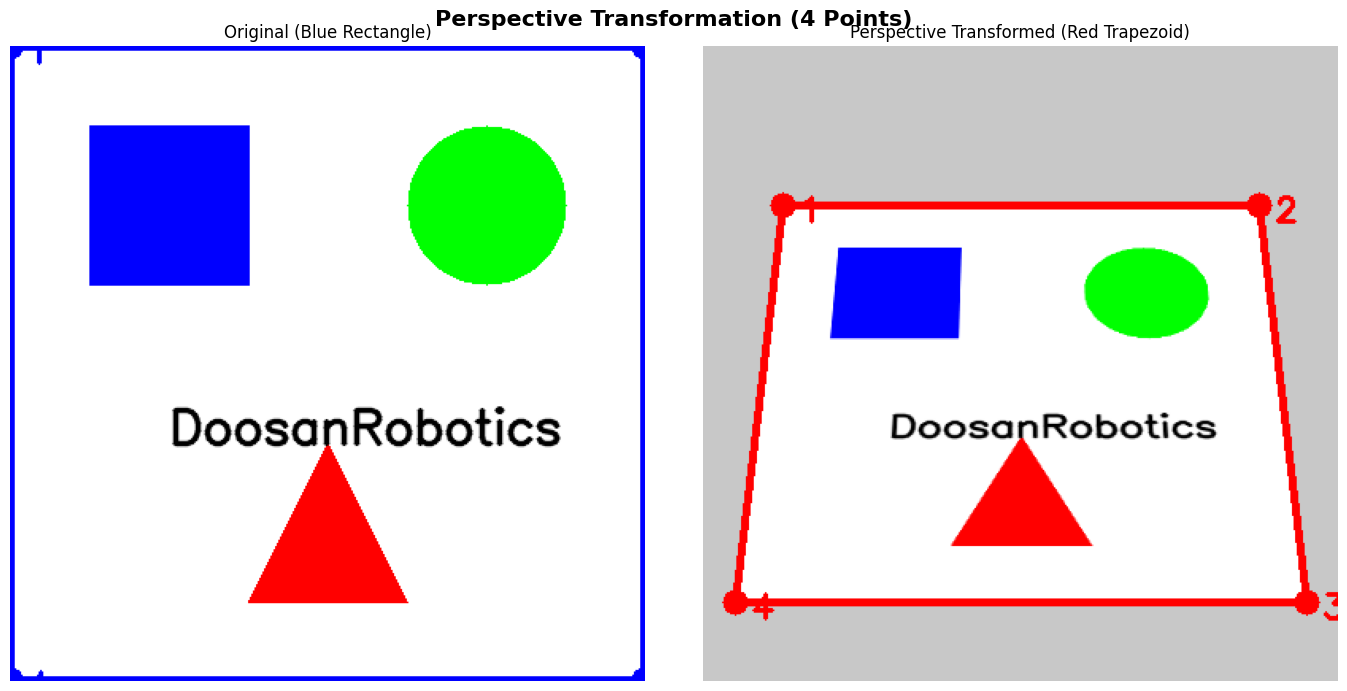

In [ ]:
# 시각화: 원본과 목표 점들을 선으로 연결
original_persp = sample_img.copy()
perspective_persp = perspective_result.copy()

# 원본 이미지에 점과 선 그리기
for i, pt in enumerate(src_pts_persp):
    # 점 그리기
    cv2.circle(
        original_persp,
        tuple(pt.astype(int)),
        8,            # 반지름
        (255, 0, 0),  # 파란색
        -1            # 다 채워라
    )
    # 점 번호 표시
    cv2.putText(
        original_persp,
        str(i+1),
        tuple((pt + [10, 10]).astype(int)), # [10,10] -> 글자위치
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

# 사각형 테두리 그리기
cv2.polylines(
    original_persp,
    [src_pts_persp.astype(int)],  # 점들을 int로 변환
    True,  # 닫힌 도형
    (255, 0, 0),  # 파란색
    3  # 선 두께
)

# 변환된 이미지에 점과 선 그리기
for i, pt in enumerate(dst_pts_persp):
    cv2.circle(
        perspective_persp,
        tuple(pt.astype(int)),
        8,
        (0, 0, 255),  # 빨간색
        -1
    )
    cv2.putText(
        perspective_persp,
        str(i+1),
        tuple((pt + [10, 10]).astype(int)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

cv2.polylines(
    perspective_persp,
    [dst_pts_persp.astype(int)],
    True,
    (0, 0, 255),  # 빨간색
    3
)

# 결과 표시
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Perspective Transformation (4 Points)', fontsize=16, fontweight='bold')

# 원본 (파란색 사각형)
axes[0].imshow(cv2.cvtColor(original_persp, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (Blue Rectangle)', fontsize=12)
axes[0].axis('off')

# 변환 결과 (빨간색 사다리꼴)
axes[1].imshow(cv2.cvtColor(perspective_persp, cv2.COLOR_BGR2RGB))
axes[1].set_title('Perspective Transformed (Red Trapezoid)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

실전예제 - ROKEY_9 DOC READER

array([[[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       ...,

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]]], dtype=uint8)
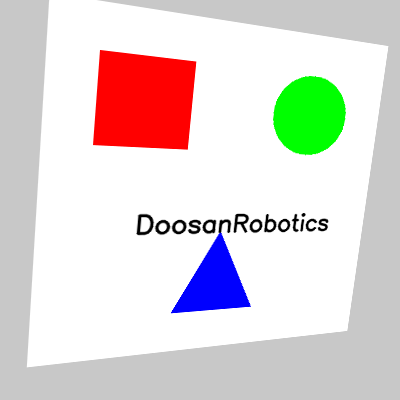

In [ ]:
# 비스듬한 문서 >> 정면으로 보정 (문서 스캐너 원리)

# 비스듬한 문서
# 원본(src) 먼저 비스듬하게 만들고 다시 정면으로 복원

# step 1 : 정면 >> 비스듬하게 (원근 효과 추가)
src = np.float32([
    [50,50],
    [width-50, 50],
    [width-50, height-50],
    [50, height-50]
])

# 비스듬한 객체 생성
dst_skew = np.float32([
    [100,50],
    [width-50, 80],
    [width-80, height-100],
    [80, height-80]
])

skew_mat = cv2.getPerspectiveTransform(src, dst_skew) # 변환행렬
skew_doc = cv2.warpPerspective(
    sample_img,
    skew_mat,
    (width, height),
    borderValue=(200,200,200)
)
skew_doc

In [ ]:
# # 비스듬한 문서 >> 정면으로 보정 (문서 스캐너 원리)

# # 비스듬한 문서
# # 원본(src) 먼저 비스듬하게 만들고 다시 정면으로 복원

# # step 1 : 정면 >> 비스듬하게 (원근 효과 추가)
# src = np.float32([
#     [50,50],
#     [width-50, 50],
#     [width-50, height-50],
#     [50, height-50]
# ])

# # 비스듬한 객체 생성
# dst_skew = np.float32([
#     [100,50],
#     [width-50, 80],
#     [width-80, height-100],
#     [80, height-80]
# ])

# skew_mat = cv2.getPerspectiveTransform(src, dst_skew) # 변환행렬
# skew_doc = cv2.warpPerspective(
#     sample_img,
#     skew_mat,
#     (width, height),
#     borderValue=(200,200,200)
# )
# skew_doc

In [ ]:
# step 2: 비스듬한 객체 >> 복원
# 역변환을 위해서 원본과 목표를 바꿈

correct_mat = cv2.getPerspectiveTransform(dst_skew, src)

correct_doc = cv2.warpPerspective(
    skew_doc,
    correct_mat,
    (width, height),
    borderValue=(255,255,255)
)

In [ ]:
# correct_mat = cv2.getPerspectiveTransform(dst_skew, src)

# correct_doc = cv2.warpPerspective(
#     skew_doc,
#     correct_mat,
#     (width, height),
#     borderValue=(255,255,255)
# )

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [241, 241, 241],
        [245, 245, 245],
        [232, 232, 232]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [234, 234, 234]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [236, 236, 236]],

       ...,

       [[253, 253, 253],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [253, 253, 253],
        [237, 237, 237]],

       [[251, 251, 251],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [234, 234, 234]],

       [[234, 234, 234],
        [241, 241, 241],
        [245, 245, 245],
        ...,
        [240, 240, 240],
        [243, 243, 243],
        [228, 228, 228]]], dtype=uint8)
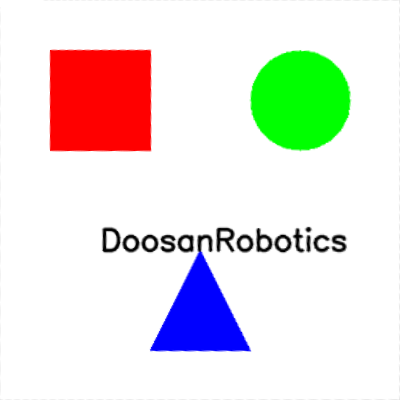

In [ ]:
correct_doc

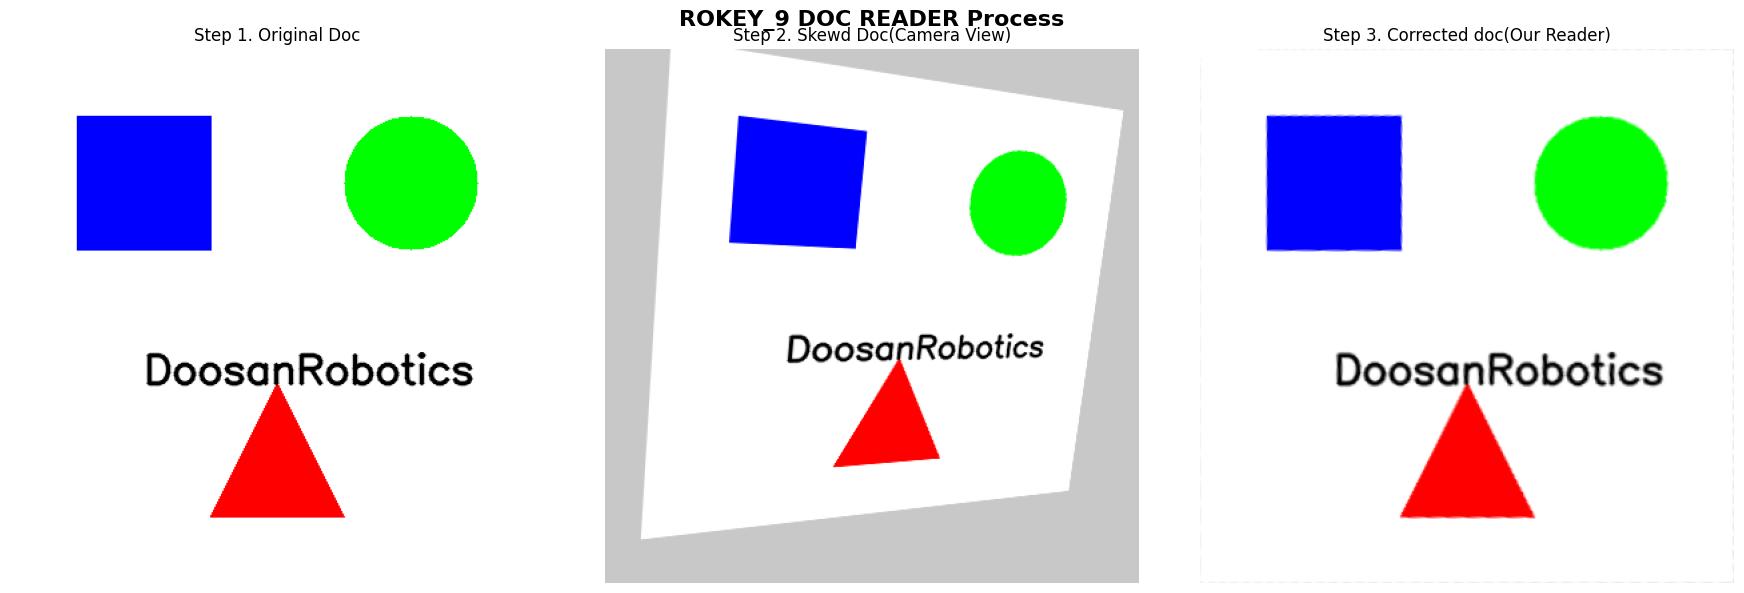

In [ ]:
# step 3 : 원본 > 비스듬한 객체 > 보정(복원)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROKEY_9 DOC READER Process', fontsize=16, fontweight='bold')

# 원본
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Step 1. Original Doc', fontsize=12)
axes[0].axis('off')

# 비스듬한 문서
axes[1].imshow(cv2.cvtColor(skew_doc, cv2.COLOR_BGR2RGB))
axes[1].set_title('Step 2. Skewd Doc(Camera View)', fontsize=12)
axes[1].axis('off')

# 우리 리더기를 통한 복원 문서
axes[2].imshow(cv2.cvtColor(correct_doc, cv2.COLOR_BGR2RGB))
axes[2].set_title('Step 3. Corrected doc(Our Reader)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()